# Fase 2 — Análise Exploratória (EDA)

**Companion: Nielsen, cap. 3.** Com os dados já compreendidos (Fase 1), olhamos a estrutura do IPCA *antes* de modelar, por quatro ângulos:

1. **Decomposição** — separar tendência, sazonalidade e resíduo.
2. **Estatísticas móveis** — diagnóstico visual de estacionariedade.
3. **Sazonalidade** — qual padrão se repete a cada ano.
4. **Autocorrelação (ACF/PACF e lag plot)** — quanto o IPCA depende do próprio passado.

> A autocorrelação responde à pergunta "dá para achar padrão correlacionando?": sim — e o primeiro padrão é a série **com ela mesma no tempo**. Correlação com *outras* variáveis vem na Fase 5.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from series_eco.data import loaders
from series_eco.eda import descriptive, plots

painel = loaders.load_panel("2000-01-01")
ipca = painel["ipca"]
painel.tail()

,ipca,cambio,selic
Date,,,
2025-12-01,0.33,5.5024,14.90
2026-01-01,0.33,5.2301,14.90
2026-02-01,0.70,5.1495,14.90
2026-03-01,0.88,5.2194,14.80
2026-04-01,0.67,4.9886,14.64


## 1. Decomposição STL do IPCA

Separamos o IPCA em **tendência** (movimento de longo prazo), **sazonalidade** (padrão que se repete a cada 12 meses) e **resíduo** (o que sobra). Se a sazonalidade for forte e estável, precisaremos de um termo sazonal no modelo (SARIMA).

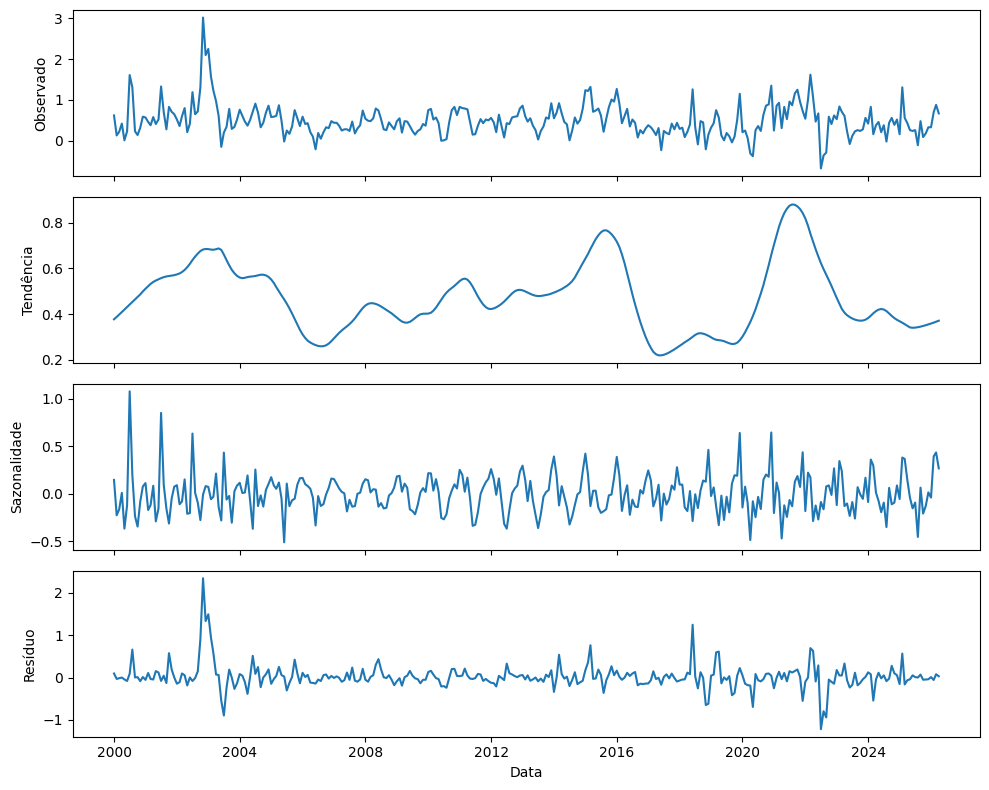

In [2]:
resultado = descriptive.decompose_stl(ipca, period=12)
descriptive.plot_decomposition(resultado)
plt.show()

## 2. Estatísticas móveis — a série é estável no tempo?

Se média e desvio móveis ficam aproximadamente constantes, isso sugere **estacionariedade** (média e variância estáveis) — pré-requisito do ARIMA. Para o IPCA, espera-se uma média móvel relativamente plana, em contraste com câmbio e Selic (Fase 1).

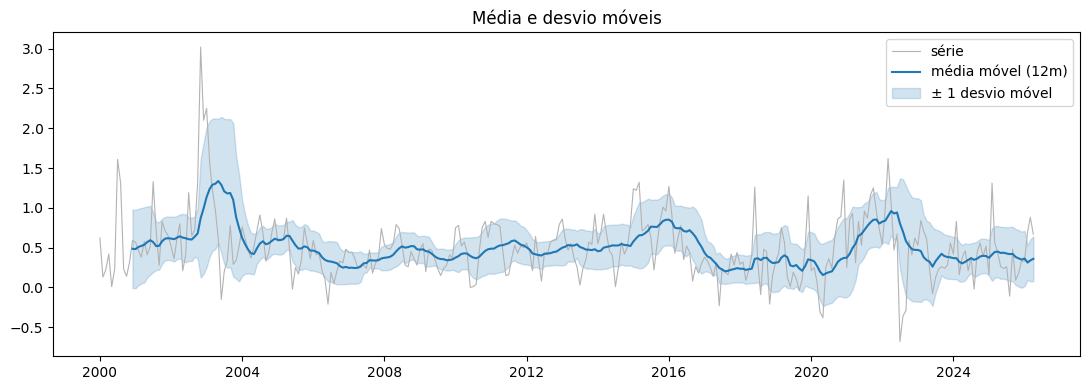

In [3]:
plots.plot_rolling_stats(ipca, window=12)
plt.show()

## 3. Sazonalidade vista de perto

O boxplot por mês mostra como a distribuição do IPCA muda ao longo do ano. Meses com mediana mais alta concentram pressão inflacionária sazonal (reajustes, alimentos, etc.).

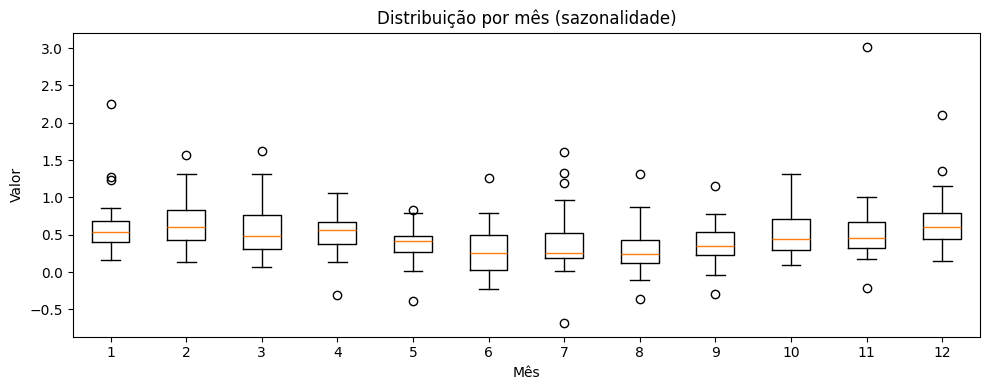

In [4]:
plots.plot_seasonal_subseries(ipca)
plt.show()

## 4. Autocorrelação: ACF, PACF e lag plot

- **ACF** (Função de Autocorrelação): correlação do IPCA com ele mesmo `k` meses atrás.
- **PACF** (Autocorrelação Parcial): o mesmo, removendo o efeito das defasagens intermediárias.
- **Lag plot**: a autocorrelação da defasagem 1 vista como nuvem de pontos — se os pontos se alinham, há dependência temporal.

A leitura da ACF/PACF guia a escolha das ordens `p` (AR) e `q` (MA) na Fase 4.

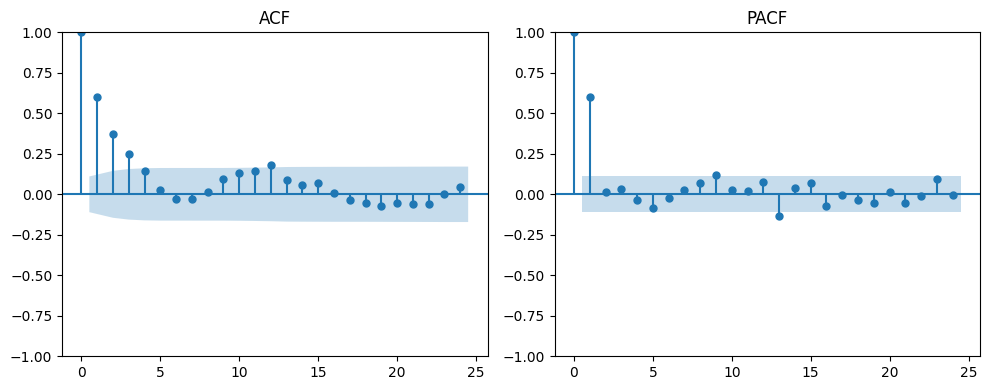

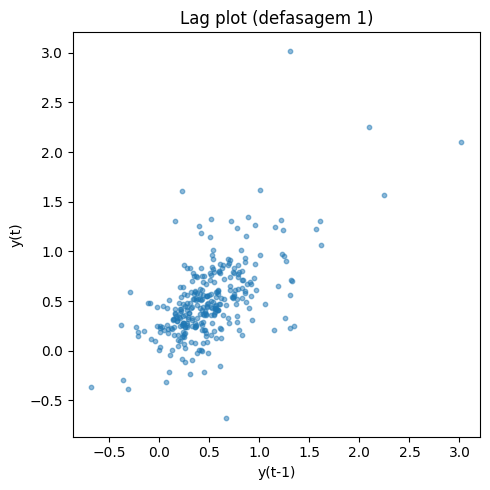

In [5]:
descriptive.plot_acf_pacf(ipca, nlags=24)
plt.show()
plots.plot_lag(ipca, lag=1)
plt.show()

## 5. Prévia da estacionariedade (Fase 3)

Se a ACF decai muito devagar, a série pode não ser estacionária. Aplicamos a **primeira diferença** (variação mês a mês) e reolhamos a autocorrelação — costuma ficar mais "limpa".

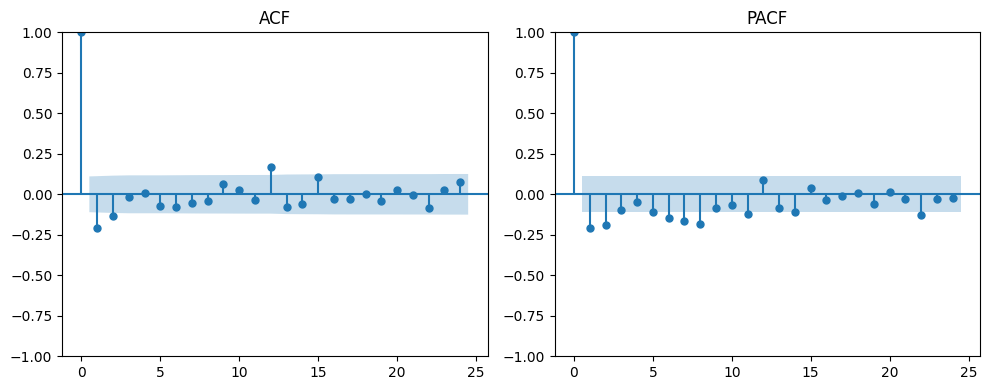

In [6]:
ipca_diff = ipca.diff().dropna()
descriptive.plot_acf_pacf(ipca_diff, nlags=24)
plt.show()

---
**Próximas fases:** Fase 3 formaliza a estacionariedade (testes ADF/KPSS); Fase 4 ajusta ARIMA/SARIMA usando as ordens sugeridas pela ACF/PACF acima; Fase 5 traz câmbio e Selic para testar correlação *cruzada* (VAR/Granger/ARIMAX).